In [1]:
# Import necessary libraries
import pandas as pd

In [16]:
df = pd.read_csv('../req/MediCare_Readmission_Intelligence.csv')

In [25]:
# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Find duplicate rows
duplicates = df[df.duplicated()]

# Display duplicate rows
print("Duplicate records found:")


Number of duplicate rows: 500
Duplicate records found:


In [26]:
# Total  records
totalRecords = df.shape[0]
print("Total Records: ", df.shape[0])

# Count occurrences of each patient_id
counts = df["patient_id"].value_counts()

# Filter only those with more than 1 occurrence (duplicates)
duplicates = counts[counts > 1]


Total Records:  50500


In [19]:
# Remove duplicates
df_cleaned = df.drop_duplicates()

# Save the cleaned DataFrame back to CSV
df_cleaned.to_csv("../temp/cleaned.csv", index=False)

print("Duplicates removed. Cleaned file saved as 'your_file_cleaned.csv'")

Duplicates removed. Cleaned file saved as 'your_file_cleaned.csv'


In [20]:
# Total  records
cdf = pd.read_csv('../temp/cleaned.csv')

totalRecords = cdf.shape[0]
print("Total Records: ", cdf.shape[0])

Total Records:  50000


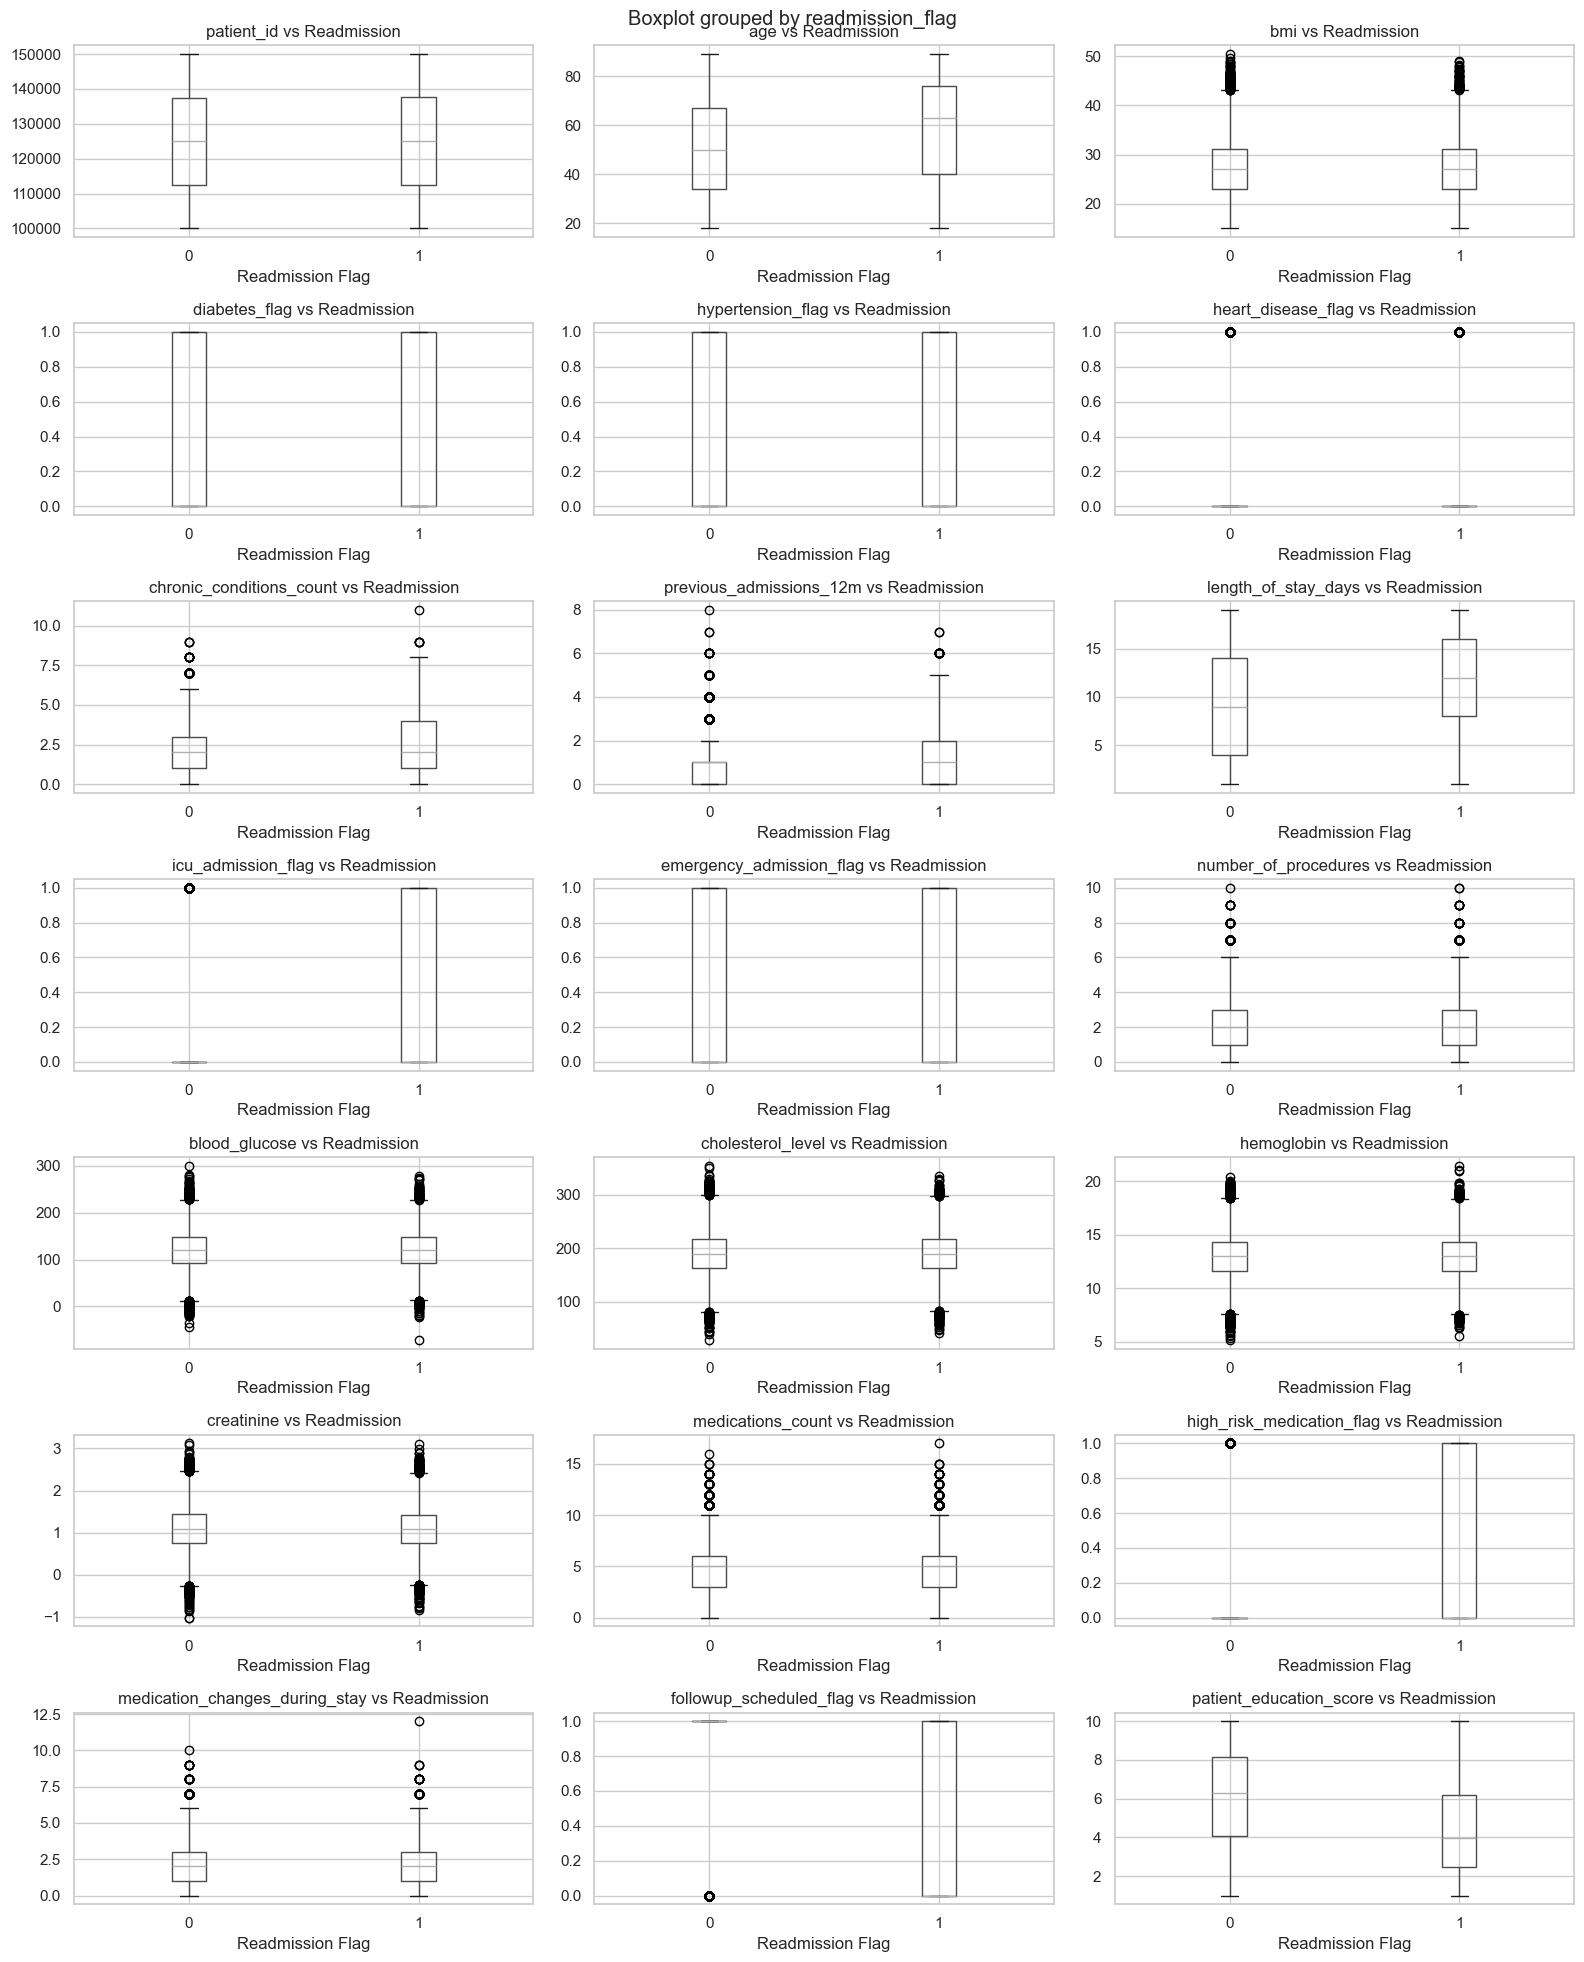

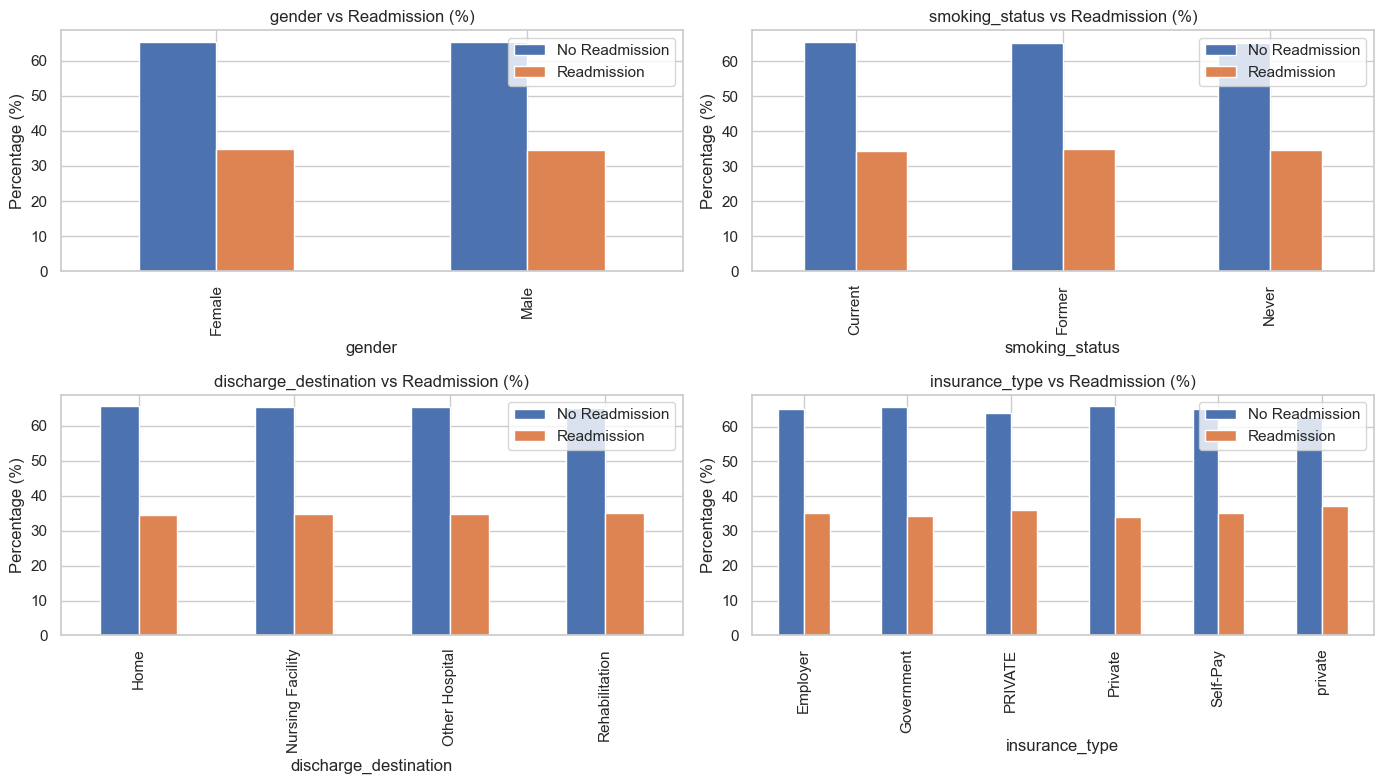

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Separate numeric and categorical columns
numeric_cols = cdf.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('readmission_flag')  # Remove target variable
categorical_cols = cdf.select_dtypes(include=['object']).columns.tolist()

# Create subplots for numeric features
fig, axes = plt.subplots(7, 3, figsize=(16, 20))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx >= len(axes):
        break
    cdf.boxplot(column=col, by='readmission_flag', ax=axes[idx])
    axes[idx].set_title(f'{col} vs Readmission')
    axes[idx].set_xlabel('Readmission Flag')

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Create plots for categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    cross_tab = pd.crosstab(cdf[col], cdf['readmission_flag'], normalize='index') * 100
    cross_tab.plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'{col} vs Readmission (%)')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(['No Readmission', 'Readmission'])

plt.tight_layout()
plt.show()

In [ ]:
```python
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

identifier_cols = [
    "patient_id",
    "legacy_record_id",
    "billing_reference_number",
    "care_cluster_id",
    "administrative_batch_id",
]
feature_cols = [col for col in cdf.columns if col not in identifier_cols + ["readmission_flag"]]

numeric_features = cdf[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = cdf[feature_cols].select_dtypes(include=["object"]).columns.tolist()

X = pd.get_dummies(cdf[feature_cols], drop_first=True)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["readmission_flag"] = cdf["readmission_flag"].astype(int)

loadings = pd.DataFrame(
    pca.components_.T, index=X.columns, columns=["PC1", "PC2", "PC3"]
)
explained = pd.Series(
    pca.explained_variance_ratio_, index=["PC1", "PC2", "PC3"]
)

numeric_corr = (
    cdf[numeric_features]
    .corrwith(cdf["readmission_flag"])
    .abs()
    .sort_values(ascending=False)
)

print("Top numeric correlations with readmission_flag:")
print(numeric_corr.head(10))
print("\nExplained variance ratio:")
print(explained)
print("\nTop loadings on PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(10))

print("\nCategorical feature mean readmission rate:")
for col in categorical_features:
    print(f"\n{col}")
    print(cdf.groupby(col)["readmission_flag"].mean().sort_values(ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="readmission_flag",
    palette="Set1",
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title("PCA: PC1 vs PC2 colored by Readmission Flag")

axes[1].bar(explained.index, explained.values)
axes[1].set_title("Explained Variance by Principal Component")
axes[1].set_ylabel("Variance Ratio")

top_loadings = loadings["PC1"].abs().sort_values(ascending=False).head(10)
axes[2].barh(top_loadings.index[::-1], top_loadings.values[::-1])
axes[2].set_title("Top 10 feature loadings on PC1")

plt.tight_layout()
plt.show()
```

Numeric features: ['age', 'bmi', 'diabetes_flag', 'hypertension_flag', 'heart_disease_flag', 'chronic_conditions_count', 'previous_admissions_12m', 'length_of_stay_days', 'icu_admission_flag', 'emergency_admission_flag', 'number_of_procedures', 'blood_glucose', 'cholesterol_level', 'hemoglobin', 'creatinine', 'medications_count', 'high_risk_medication_flag', 'medication_changes_during_stay', 'followup_scheduled_flag', 'patient_education_score']
Categorical features: ['gender', 'smoking_status', 'discharge_destination', 'insurance_type']
Top numeric correlations with readmission_flag:
followup_scheduled_flag      0.319066
patient_education_score      0.284304
icu_admission_flag           0.250027
high_risk_medication_flag    0.189044
chronic_conditions_count     0.176655
length_of_stay_days          0.171898
age                          0.168278
previous_admissions_12m      0.125993
emergency_admission_flag     0.011027
hemoglobin                   0.006985
dtype: float64

Explained var

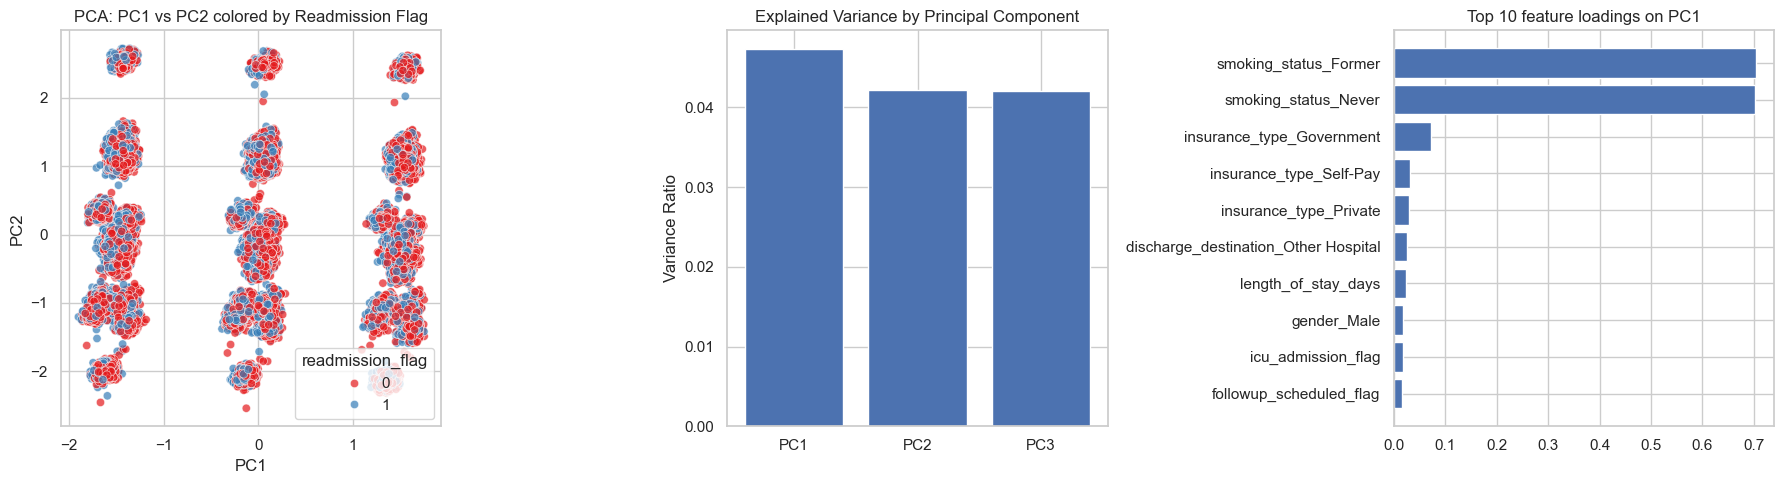

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

identifier_cols = [
    "patient_id",
    "legacy_record_id",
    "billing_reference_number",
    "care_cluster_id",
    "administrative_batch_id",
]
feature_cols = [col for col in cdf.columns if col not in identifier_cols + ["readmission_flag"]]

numeric_features = [col for col in cdf[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist() if col != 'treatment_cost']
print("Numeric features:", numeric_features)        



categorical_features = cdf[feature_cols].select_dtypes(include=["object"]).columns.tolist()
print("Categorical features:", categorical_features)

X = pd.get_dummies(cdf[feature_cols], drop_first=True)
X_scaled = StandardScaler().fit_transform(X)

# Handle NaN values before PCA
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_scaled)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_imputed)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["readmission_flag"] = cdf["readmission_flag"].astype(int)

loadings = pd.DataFrame(
    pca.components_.T, index=X.columns, columns=["PC1", "PC2", "PC3"]
)
explained = pd.Series(
    pca.explained_variance_ratio_, index=["PC1", "PC2", "PC3"]
)

numeric_corr = (
    cdf[numeric_features]
    .corrwith(cdf["readmission_flag"])
    .abs()
    .sort_values(ascending=False)
)

print("Top numeric correlations with readmission_flag:")
print(numeric_corr.head(10))
print("\nExplained variance ratio:")
print(explained)
print("\nTop loadings on PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(10))

print("\nCategorical feature mean readmission rate:")
for col in categorical_features:
    print(f"\n{col}")
    print(cdf.groupby(col)["readmission_flag"].mean().sort_values(ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="readmission_flag",
    palette="Set1",
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title("PCA: PC1 vs PC2 colored by Readmission Flag")

axes[1].bar(explained.index, explained.values)
axes[1].set_title("Explained Variance by Principal Component")
axes[1].set_ylabel("Variance Ratio")

top_loadings = loadings["PC1"].abs().sort_values(ascending=False).head(10)
axes[2].barh(top_loadings.index[::-1], top_loadings.values[::-1])
axes[2].set_title("Top 10 feature loadings on PC1")

plt.tight_layout()
plt.show()